In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# Loading my combined residential dataset from previous weeks
df_sold = pd.read_csv('combined_sold_residential.csv') 
df_sold['CloseDate'] = pd.to_datetime(df_sold['CloseDate'])

print(f"Dataset successfully loaded: {df_sold.shape[0]} rows.")

/var/folders/79/69blhrkx76v97b9l62mk04600000gn/T/ipykernel_23715/1375272333.py:8: DtypeWarning: Columns (0: BuyerAgentAOR, 1: ListAgentAOR, 2: WaterfrontYN, 3: ListAgentEmail, 4: latfilled, 5: lonfilled, 6: OriginatingSystemName, 7: OriginatingSystemSubName, 8: BuyerAgencyCompensationType) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sold = pd.read_csv('combined_sold_residential.csv')


Dataset successfully loaded: 381850 rows.


/var/folders/79/69blhrkx76v97b9l62mk04600000gn/T/ipykernel_23715/1375272333.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_sold['CloseDate'] = pd.to_datetime(df_sold['CloseDate'])


In [32]:
# Phase 2: Loading Mortgage Data using the direct FRED CSV link
# I'm using the same method as my previous script for consistency
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"

try:
    # Reading the data directly from the FRED URL
    mortgage = pd.read_csv(url)
    mortgage.columns = ['DATE', 'rate_30yr_fixed']
    mortgage['DATE'] = pd.to_datetime(mortgage['DATE'])
    
    # Converting to monthly averages to align with my sales data
    mortgage['year_month'] = mortgage['DATE'].dt.to_period('M')
    mortgage_monthly = mortgage.groupby('year_month')['rate_30yr_fixed'].mean().reset_index()
    
    # Prepping for the merge
    mortgage_monthly['Month_Year'] = mortgage_monthly['year_month'].dt.to_timestamp()
    df_sold['Month_Year'] = df_sold['CloseDate'].dt.to_period('M').dt.to_timestamp()
    
    # Merging the datasets
    final_df = pd.merge(df_sold, mortgage_monthly, on='Month_Year', how='left')
    print("✅ Mortgage data successfully fetched and merged.")
    
except Exception as e:
    print(f"❌ Mortgage Download Failed: {e}")

✅ Mortgage data successfully fetched and merged.


In [33]:
# Calculating the percentage of missing values to identify columns I should drop
null_report = (final_df.isnull().mean() * 100).to_frame(name='Percent_Missing')
high_null_cols = null_report[null_report['Percent_Missing'] > 90].sort_values(by='Percent_Missing', ascending=False)

print("--- COLUMNS I FLAGGED FOR REMOVAL (>90% MISSING) ---")
display(high_null_cols)

--- COLUMNS I FLAGGED FOR REMOVAL (>90% MISSING) ---


,Percent_Missing
ElementarySchoolDistrict,100.000000
BusinessType,100.000000
FireplacesTotal,100.000000
AboveGradeFinishedArea,100.000000
TaxAnnualAmount,100.000000
MiddleOrJuniorSchoolDistrict,100.000000
TaxYear,100.000000
CoveredSpaces,100.000000
WaterfrontYN,99.937148
BelowGradeFinishedArea,99.424643


In [34]:
# I'm defining a function to calculate outlier boundaries for any numeric column
def get_outlier_stats(df, col):
    # Removing nulls to ensure calculation accuracy
    data = df[col].dropna()
    q1, q3 = data.quantile([0.25, 0.75])
    iqr = q3 - q1
    
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = data[(data < lower) | (data > upper)]
    
    return {
        "Column": col,
        "Median": data.median(),
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": len(outliers),
        "Outlier_Pct": round((len(outliers) / len(data)) * 100, 2) if len(data) > 0 else 0
    }

# Identifying all numeric fields in my dataset
numeric_fields = final_df.select_dtypes(include=['number']).columns

# Running the scan across every numeric column and converting to a summary table
my_outlier_report = pd.DataFrame([get_outlier_stats(final_df, col) for col in numeric_fields])

print("--- COMPREHENSIVE DATA QUALITY AUDIT: OUTLIERS ---")
display(my_outlier_report.sort_values(by="Outlier_Pct", ascending=False))

--- COMPREHENSIVE DATA QUALITY AUDIT: OUTLIERS ---


,Column,Median,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Pct
27,GarageSpaces,2.000000e+00,2.000000e+00,2.000000e+00,136771,37.42
3,Latitude,3.404758e+01,3.251109e+01,3.578206e+01,74717,20.41
4,Longitude,-1.180158e+02,-1.213107e+02,-1.148444e+02,67382,18.40
21,BelowGradeFinishedArea,0.000000e+00,0.000000e+00,0.000000e+00,389,17.71
29,LotSizeSquareFeet,7.236000e+03,-4.575500e+03,2.156450e+04,55280,15.71
13,LotSizeAcres,1.663000e-01,-1.062000e-01,4.970000e-01,55182,15.69
25,LotSizeArea,7.013000e+03,-3.835000e+03,1.972500e+04,53152,15.10
12,ParkingTotal,2.000000e+00,5.000000e-01,4.500000e+00,57218,15.00
15,StreetNumberNumeric,3.295000e+03,-1.551100e+04,2.852900e+04,33570,8.80
0,OriginalListPrice,8.250000e+05,-4.860000e+05,2.370000e+06,29621,7.77


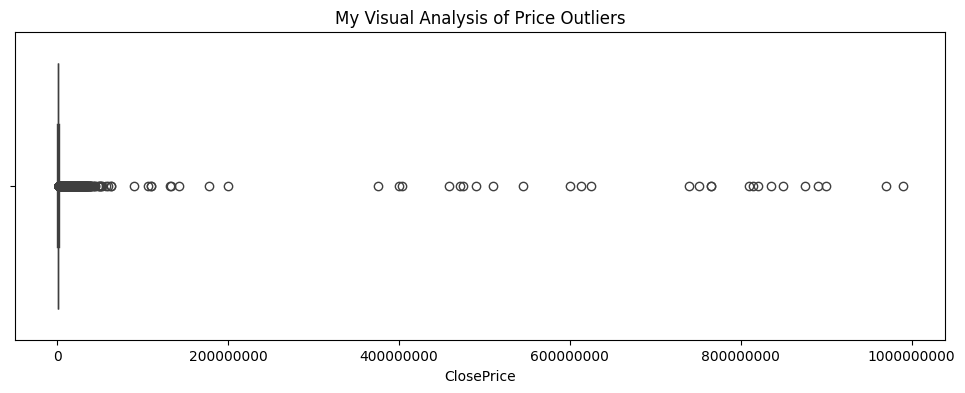

In [35]:
# Creating a boxplot to visually demonstrate the spread of price outliers
plt.figure(figsize=(12, 4))
sns.boxplot(x=final_df['ClosePrice'])
plt.title('My Visual Analysis of Price Outliers')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

In [36]:
# Analyzing property type distribution
prop_share = final_df['PropertyType'].value_counts(normalize=True) * 100
print("--- Property Type Share ---")
print(prop_share)

# Calculating Price Stats
print(f"\nAverage Close Price: ${final_df['ClosePrice'].mean():,.2f}")
print(f"Median Close Price: ${final_df['ClosePrice'].median():,.2f}")

--- Property Type Share ---
PropertyType
Residential    100.0
Name: proportion, dtype: float64

Average Close Price: $1,186,039.01
Median Close Price: $821,259.50


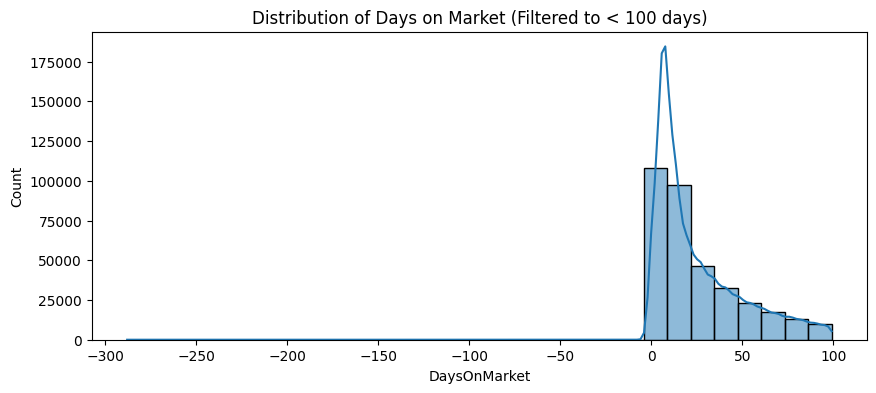

Percentage sold ABOVE list: 40.19%
Percentage sold AT or BELOW list: 59.81%


In [37]:
# 1. DOM Distribution
plt.figure(figsize=(10, 4))
sns.histplot(final_df[final_df['DaysOnMarket'] < 100]['DaysOnMarket'], bins=30, kde=True)
plt.title('Distribution of Days on Market (Filtered to < 100 days)')
plt.show()

# 2. List Price vs Close Price
# Create a column to see if it sold for more than list
final_df['Sold_Over_List'] = final_df['ClosePrice'] > final_df['ListPrice']
over_under = final_df['Sold_Over_List'].value_counts(normalize=True) * 100

print(f"Percentage sold ABOVE list: {over_under[True]:.2f}%")
print(f"Percentage sold AT or BELOW list: {over_under[False]:.2f}%")

In [38]:
# Logic check: CloseDate should always be after ListingDate
final_df['ListDate'] = pd.to_datetime(final_df['ListingContractDate'])
inconsistent_dates = final_df[final_df['CloseDate'] < final_df['ListDate']]

print(f"Number of records where Close Date is before List Date: {len(inconsistent_dates)}")
if len(inconsistent_dates) > 0:
    print("Example of inconsistency:")
    display(inconsistent_dates[['ListingId', 'ListDate', 'CloseDate']].head(3))

Number of records where Close Date is before List Date: 56
Example of inconsistency:


/var/folders/79/69blhrkx76v97b9l62mk04600000gn/T/ipykernel_23715/2619133274.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  final_df['ListDate'] = pd.to_datetime(final_df['ListingContractDate'])


,ListingId,ListDate,CloseDate
2009,24418631,2024-10-02,2024-09-19
2199,24428772,2024-09-30,2024-09-05
2833,24426755,2024-09-28,2024-09-24


In [39]:
# Grouping by County to find the most expensive areas
county_stats = final_df.groupby('CountyOrParish')['ClosePrice'].median().sort_values(ascending=False)
print("--- Top 5 Counties by Median Price ---")
print(county_stats.head(5))

--- Top 5 Counties by Median Price ---
CountyOrParish
Del Norte       2485000.0
Other County    2462500.0
San Mateo       1700000.0
Santa Clara     1600000.0
Santa Cruz      1195000.0
Name: ClosePrice, dtype: float64


In [40]:
# 1. Load Listings (Assuming you have combined_listings_residential.csv)
df_listed = pd.read_csv('combined_listings_residential.csv')
df_listed['Month_Year'] = pd.to_datetime(df_listed['ListingContractDate']).dt.to_period('M').dt.to_timestamp()

# 2. Merge FRED onto Listings
final_listings = pd.merge(df_listed, mortgage_monthly, on='Month_Year', how='left')

# 3. Validation Check (Null rate)
null_rate_sold = final_df['rate_30yr_fixed'].isnull().mean()
null_rate_listed = final_listings['rate_30yr_fixed'].isnull().mean()

print(f"Validation: Mortgage Null Rate in Sold: {null_rate_sold*100}%")
print(f"Validation: Mortgage Null Rate in Listings: {null_rate_listed*100}%")

# 4. Save to CSV
final_df.to_csv('sold_enriched.csv', index=False)
final_listings.to_csv('listed_enriched.csv', index=False)
print("✅ Files saved: sold_enriched.csv and listed_enriched.csv")


/var/folders/79/69blhrkx76v97b9l62mk04600000gn/T/ipykernel_23715/1443371372.py:2: DtypeWarning: Columns (0: ListAgentEmail, 1: BuyerAgencyCompensationType) have mixed types. Specify dtype option on import or set low_memory=False.
  df_listed = pd.read_csv('combined_listings_residential.csv')


Validation: Mortgage Null Rate in Sold: 0.0%
Validation: Mortgage Null Rate in Listings: 0.0%
✅ Files saved: sold_enriched.csv and listed_enriched.csv
